# DLinear reproduction on ILI (second check of the app's implementation)

Companion to `dlinear_traffic_reproduction.ipynb`. ILI is tiny (966 weekly rows, 7 variables), so this runs in
minutes and gives a fast second test of the paper's claim, on a dataset where the paper's table has very
different (much larger) errors than Traffic.

The network class is **imported from the app** (`_DLinearNet`); only the experimental protocol follows the paper:
70/10/20 chronological split, z-score fit on train, every sliding test window, pooled MSE/MAE on normalized data,
horizons T = 24, 36, 48, 60.

**Paper values, DLinear column, ILI (Table 2 of `docs/Dlinear.pdf`):**

| T | MSE | MAE |
|---|---|---|
| 24 | 2.215 | 1.081 |
| 36 | 1.963 | 0.963 |
| 48 | 2.130 | 1.024 |
| 60 | 2.368 | 1.096 |

**Look-back is not stated for the Linear models in the paper's Table 2.** The paper only says 96 for the Transformer
baselines. On Traffic, the paper's numbers reproduced at L = 336, not 96. For ILI, 36 is the usual Informer-style
setting for the Transformer baselines; the official DLinear ILI script (`ili.sh`) uses seq_len 104, batch 32, lr 0.05.
Both are run below and both are reported; neither is chosen by test error.

**Not paper-comparable on purpose:** ILI has only about 190 test rows, so with L = 104 and T = 60 there are
only ~30 test windows. The metric is noisy, so each setting is trained with 5 seeds and reported as mean +/- std
(the paper reports one run).

In [1]:
import sys, time
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
while not (ROOT / "backend").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "backend" / "app" / "forecasting"))   # same trick as forecasting_bridge.py
from models.dlinear import _DLinearNet                              # <-- the app's own DLinear network

torch.set_num_threads(8)
DEVICE = torch.device("cpu")

CFG = dict(pred_lens=[24, 36, 48, 60], look_backs=[36, 104], epochs=10, patience=3, batch_size=32,
           seeds=[2021, 2022, 2023, 2024, 2025], moving_avg_kernel=25)
PAPER = {24: (2.215, 1.081), 36: (1.963, 0.963), 48: (2.130, 1.024), 60: (2.368, 1.096)}

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1. Data (same file the app loads)

In [2]:
df = pd.read_csv(ROOT / "backend/data/ili/national_illness.csv")
raw = df.select_dtypes(include=[np.number]).values.astype(np.float32)   # drops the date column, like the loader
print("shape (weeks, variables):", raw.shape, "| columns:", list(df.select_dtypes(include=[np.number]).columns))
assert raw.shape == (966, 7)         # paper Table 1: ILI, 7 variates, 966 steps

shape (weeks, variables): (966, 7) | columns: ['% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 5-24', 'ILITOTAL', 'NUM. OF PROVIDERS', 'OT']


## 2. Paper split, lazy windows, evaluation, training (same helpers as the Traffic notebook)

In [3]:
def paper_split(values, L, train_ratio=0.7, test_ratio=0.2):
    N = len(values)
    n_train, n_test = int(N * train_ratio), int(N * test_ratio)
    n_val = N - n_train - n_test
    b1 = [0, n_train - L, N - n_test - L]
    b2 = [n_train, n_train + n_val, N]
    scaler = StandardScaler().fit(values[b1[0]:b2[0]])
    z = scaler.transform(values).astype(np.float32)
    return [z[b1[i]:b2[i]] for i in range(3)], scaler

def n_windows(series, L, T):
    return len(series) - L - T + 1

def get_batch(series_t, idx, L, T):
    x = series_t[idx[:, None] + torch.arange(L)]
    y = series_t[idx[:, None] + L + torch.arange(T)]
    return x, y

@torch.no_grad()
def evaluate(model, series_t, L, T, bs=64):
    model.eval()
    n = n_windows(series_t.numpy(), L, T)
    per_win, abs_sum, cnt = [], 0.0, 0
    for s in range(0, n, bs):
        idx = torch.arange(s, min(s + bs, n))
        x, y = get_batch(series_t, idx, L, T)
        err = model(x.to(DEVICE)) - y.to(DEVICE)
        per_win.append((err ** 2).mean(dim=(1, 2)))
        abs_sum += err.abs().sum().item(); cnt += err.numel()
    per_win = torch.cat(per_win)
    return per_win.mean().item(), abs_sum / cnt, per_win.numpy()

def train_dlinear(train_s, val_s, L, T, C, lr, seed, cfg=CFG):
    torch.manual_seed(seed); np.random.seed(seed)
    model = _DLinearNet(L, T, C, cfg["moving_avg_kernel"]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    tr_t, va_t = torch.from_numpy(train_s), torch.from_numpy(val_s)
    n = n_windows(train_s, L, T)
    best, best_state, bad, hist = float("inf"), None, 0, []
    for epoch in range(1, cfg["epochs"] + 1):
        for g in opt.param_groups:
            g["lr"] = lr * (0.5 ** (epoch - 1))              # official 'type1' schedule
        model.train()
        perm = torch.randperm(n)
        for s in range(0, n, cfg["batch_size"]):
            x, y = get_batch(tr_t, perm[s:s + cfg["batch_size"]], L, T)
            opt.zero_grad(); loss_fn(model(x.to(DEVICE)), y.to(DEVICE)).backward(); opt.step()
        v, _, _ = evaluate(model, va_t, L, T)
        hist.append(v)
        if v < best - 1e-6:
            best, bad = v, 0; best_state = {k: t.clone() for k, t in model.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]: break
    model.load_state_dict(best_state)
    return model, hist

C = raw.shape[1]
for L in CFG["look_backs"]:
    (tr, va, te), _ = paper_split(raw, L)
    print(f"L={L}: train/val/test rows {len(tr)}/{len(va)}/{len(te)};",
          "test windows per horizon:", {T: n_windows(te, L, T) for T in CFG["pred_lens"]})

L=36: train/val/test rows 676/133/229; test windows per horizon: {24: 170, 36: 158, 48: 146, 60: 134}
L=104: train/val/test rows 676/201/297; test windows per horizon: {24: 170, 36: 158, 48: 146, 60: 134}


## 3. Learning rate chosen on validation only

The paper does not list it. Candidates 0.01 and 0.001, picked per look-back by mean
validation MSE at T = 24 over the seeds. **Caveat:** on this tiny validation set the two can be nearly tied
(at L = 104 the difference is 0.0005), so the pick is close to arbitrary. Section 4 therefore reports both the
validation-selected learning rate and the official script's 0.05, labelled separately.

In [4]:
BEST_LR = {}
for L in CFG["look_backs"]:
    (tr, va, te), _ = paper_split(raw, L)
    scores = {}
    for lr in [0.01, 0.001]:
        scores[lr] = np.mean([min(train_dlinear(tr, va, L, 24, C, lr, s)[1]) for s in CFG["seeds"]])
    BEST_LR[L] = min(scores, key=scores.get)
    print(f"L={L}: val MSE by lr {({k: round(v, 4) for k, v in scores.items()})} -> lr {BEST_LR[L]}")

L=36: val MSE by lr {0.01: 0.3756, 0.001: 0.6689} -> lr 0.01


L=104: val MSE by lr {0.01: 0.2856, 0.001: 0.2851} -> lr 0.001


## 4. Train every (look-back, horizon), all test windows, 5 seeds

In [5]:
OFFICIAL_LR = 0.05        # learning rate in the official DLinear ILI script (scripts/EXP-LongForecasting/DLinear/ili.sh)
rows, perwin = [], {}
for rule in ["val-selected", "official-0.05"]:
  for L in CFG["look_backs"]:
    lr = BEST_LR[L] if rule == "val-selected" else OFFICIAL_LR
    (tr, va, te), _ = paper_split(raw, L)
    te_t = torch.from_numpy(te)
    for T in CFG["pred_lens"]:
        t0 = time.time(); mses, maes = [], []
        for s in CFG["seeds"]:
            m, _ = train_dlinear(tr, va, L, T, C, lr, s)
            mse, mae, pw = evaluate(m, te_t, L, T)
            mses.append(mse); maes.append(mae)
            if s == CFG["seeds"][0]: perwin[(rule, L, T)] = pw
        pm, pa = PAPER[T]
        rows.append(dict(rule=rule, lr=lr, L=L, T=T, windows=len(pw), MSE=np.mean(mses), MSE_std=np.std(mses), paper_MSE=pm,
                         MSE_diff_pct=100 * (np.mean(mses) - pm) / pm,
                         MAE=np.mean(maes), MAE_std=np.std(maes), paper_MAE=pa,
                         MAE_diff_pct=100 * (np.mean(maes) - pa) / pa))
        print(f"{rule:<13} lr={lr:<6} L={L:<3} T={T}: MSE {np.mean(mses):.3f}+/-{np.std(mses):.3f} (paper {pm})  "
              f"MAE {np.mean(maes):.3f} (paper {pa})  [{time.time()-t0:.0f}s]")
res = pd.DataFrame(rows).round(3)
res

val-selected  lr=0.01   L=36  T=24: MSE 2.800+/-0.086 (paper 2.215)  MAE 1.148 (paper 1.081)  [1s]


val-selected  lr=0.01   L=36  T=36: MSE 2.757+/-0.044 (paper 1.963)  MAE 1.144 (paper 0.963)  [1s]


val-selected  lr=0.01   L=36  T=48: MSE 2.748+/-0.084 (paper 2.13)  MAE 1.137 (paper 1.024)  [0s]


val-selected  lr=0.01   L=36  T=60: MSE 2.906+/-0.063 (paper 2.368)  MAE 1.183 (paper 1.096)  [0s]


val-selected  lr=0.001  L=104 T=24: MSE 2.691+/-0.016 (paper 2.215)  MAE 1.187 (paper 1.081)  [1s]


...

official-0.05 lr=0.05   L=104 T=24: MSE 2.206+/-0.029 (paper 2.215)  MAE 1.034 (paper 1.081)  [1s]


official-0.05 lr=0.05   L=104 T=36: MSE 2.231+/-0.046 (paper 1.963)  MAE 1.053 (paper 0.963)  [1s]


official-0.05 lr=0.05   L=104 T=48: MSE 2.261+/-0.114 (paper 2.13)  MAE 1.075 (paper 1.024)  [1s]


official-0.05 lr=0.05   L=104 T=60: MSE 2.432+/-0.044 (paper 2.368)  MAE 1.118 (paper 1.096)  [1s]


,rule,lr,L,T,windows,MSE,MSE_std,paper_MSE,MSE_diff_pct,MAE,MAE_std,paper_MAE,MAE_diff_pct
0,val-selected,0.010,36,24,170,2.800,0.086,2.215,26.413,1.148,0.028,1.081,6.211
1,val-selected,0.010,36,36,158,2.757,0.044,1.963,40.449,1.144,0.011,0.963,18.766
2,val-selected,0.010,36,48,146,2.748,0.084,2.130,29.023,1.137,0.026,1.024,11.057
3,val-selected,0.010,36,60,134,2.906,0.063,2.368,22.704,1.183,0.016,1.096,7.968
4,val-selected,0.001,104,24,170,2.691,0.016,2.215,21.498,1.187,0.005,1.081,9.761
5,val-selected,0.001,104,36,158,2.707,0.039,1.963,37.887,1.187,0.012,0.963,23.305
6,val-selected,0.001,104,48,146,2.674,0.022,2.130,25.563,1.175,0.006,1.024,14.703
7,val-selected,0.001,104,60,134,2.819,0.019,2.368,19.053,1.208,0.004,1.096,10.183
8,official-0.05,0.050,36,24,170,2.933,0.207,2.215,32.429,1.177,0.051,1.081,8.889
9,official-0.05,0.050,36,36,158,2.721,0.086,1.963,38.603,1.124,0.034,0.963,16.679


## 5. Verdict

For each look-back: how far are we from the paper, and is the paper's value inside our seed-to-seed spread?
Because ILI has so few test windows, "within about 10 %" or "within 2 standard deviations" is the realistic bar,
not the 5 % used for Traffic.

--- lr rule: official-0.05, look-back L=36 (lr=0.05) ---
 T  windows   MSE  MSE_std  paper_MSE  MSE_diff_pct   MAE  paper_MAE  MAE_diff_pct  paper_within_2std
24      170 2.933    0.207      2.215        32.429 1.177      1.081         8.889              False
36      158 2.721    0.086      1.963        38.603 1.124      0.963        16.679              False
48      146 2.770    0.031      2.130        30.064 1.152      1.024        12.497              False
60      134 2.864    0.063      2.368        20.951 1.171      1.096         6.809              False
all horizons within 10% MSE: False

--- lr rule: official-0.05, look-back L=104 (lr=0.05) ---
 T  windows   MSE  MSE_std  paper_MSE  MSE_diff_pct   MAE  paper_MAE  MAE_diff_pct  paper_within_2std
24      170 2.206    0.029      2.215        -0.395 1.034      1.081        -4.366               True
36      158 2.231    0.046      1.963        13.649 1.053      0.963         9.390              False
48      146 2.261    0.114      2

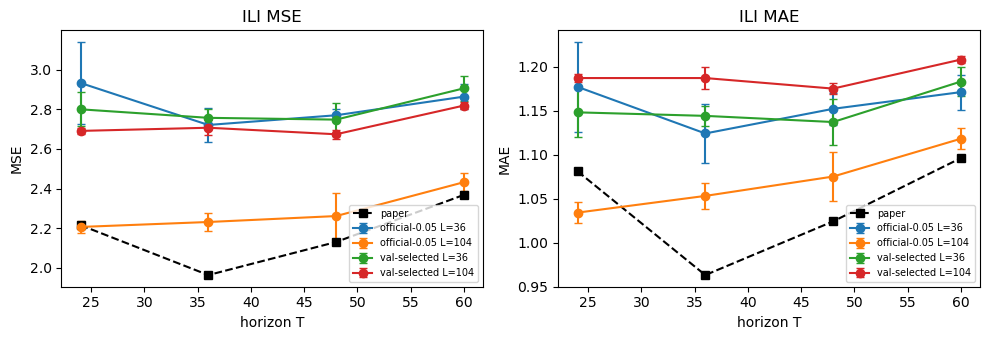

In [6]:
res["paper_within_2std"] = (res.paper_MSE - res.MSE).abs() <= 2 * res.MSE_std
for (rule, L), g in res.groupby(["rule", "L"]):
    print(f"--- lr rule: {rule}, look-back L={L} (lr={g.lr.iloc[0]}) ---")
    print(g[["T", "windows", "MSE", "MSE_std", "paper_MSE", "MSE_diff_pct", "MAE", "paper_MAE", "MAE_diff_pct", "paper_within_2std"]].to_string(index=False))
    print(f"all horizons within 10% MSE: {bool((g.MSE_diff_pct.abs() <= 10).all())}\n")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for a, k in zip(ax, ["MSE", "MAE"]):
    for (rule, L), g in res.groupby(["rule", "L"]):
        a.errorbar(g["T"].values, g[k].values, yerr=g[k + "_std"].values, marker="o", capsize=3, label=f"{rule} L={L}")
    a.plot(list(PAPER), [PAPER[t][0 if k == "MSE" else 1] for t in PAPER], "ks--", label="paper")
    a.set_xlabel("horizon T"); a.set_ylabel(k); a.set_title(f"ILI {k}"); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 6. Spread of per-window error (why a single window is unreliable)

Same trained models (first seed), the error of every individual test window. The app scores one window; the
paper averages all of them. ILI makes the difference extreme because flu error is dominated by whether a window
contains the winter peak.

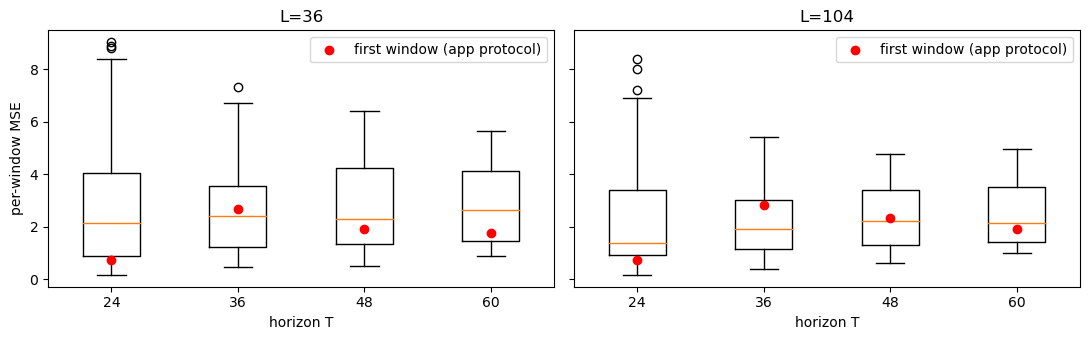

,L,T,all_windows,first_window,min,max
0,36,24,2.856,0.719,0.160,9.047
1,36,36,2.647,2.661,0.472,7.316
2,36,48,2.738,1.914,0.514,6.403
3,36,60,2.860,1.772,0.896,5.644
4,104,24,2.161,0.720,0.162,8.386
5,104,36,2.267,2.816,0.407,5.419
6,104,48,2.373,2.330,0.618,4.792
7,104,60,2.515,1.907,1.007,4.955


In [7]:
fig, ax = plt.subplots(1, len(CFG["look_backs"]), figsize=(11, 3.5), sharey=True)
for a, L in zip(np.atleast_1d(ax), CFG["look_backs"]):
    a.boxplot([perwin[("official-0.05", L, T)] for T in CFG["pred_lens"]], labels=CFG["pred_lens"], showfliers=True)
    a.scatter(range(1, 5), [perwin[("official-0.05", L, T)][0] for T in CFG["pred_lens"]], c="r", zorder=3, label="first window (app protocol)")
    a.set_title(f"L={L}"); a.set_xlabel("horizon T"); a.legend()
np.atleast_1d(ax)[0].set_ylabel("per-window MSE"); plt.tight_layout(); plt.show()
pd.DataFrame([dict(L=L, T=T, all_windows=pw.mean(), first_window=pw[0], min=pw.min(), max=pw.max())
              for (rule, L, T), pw in perwin.items() if rule == "official-0.05"]).round(3)

## 7. Conclusions

*(see the tables above)*